# Phase 4 — Feature Engineering

## Goal
Transform raw financial metrics into meaningful ratio features.
Remove size bias that dominated our EDA analysis.
Create the signals our ML model needs to predict financial distress.

## Why Feature Engineering Matters
Raw metrics tell us: "Apple has $50B cash"
Ratio features tell us: "Apple can cover its debts 3x over with cash alone"

The second statement is meaningful regardless of company size.
A $1B company and a $100B company can both have a 3x cash coverage ratio.
This is what our ML model needs — size-independent signals.

## What We Will Build
1. Liquidity Ratios — can the company pay its short term bills?
2. Solvency Ratios — can the company survive long term?
3. Profitability Ratios — is the business making money?
4. Cash Flow Ratios — is cash flow healthy relative to obligations?

## Input
data/processed/companies_clean.csv — our cleaned dataset from Phase 3

## Output
data/processed/companies_features.csv — enriched dataset with ratio features
Ready for ML modeling in Phase 5

In [6]:
# Cell 1 — Import tools and load clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the clean data we prepared in Phase 3
df = pd.read_csv('../data/processed/companies_clean.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nHealthy companies: {len(df[df['status'] == 'Healthy'])}")
print(f"Distressed companies: {len(df[df['status'] == 'Distressed'])}")
print(f"\nColumns available:")
for col in df.columns:
    print(f"  - {col}")

Data loaded successfully!
Shape: (60, 22)

Healthy companies: 30
Distressed companies: 30

Columns available:
  - company
  - label
  - status
  - Revenues
  - NetIncomeLoss
  - OperatingIncomeLoss
  - GrossProfit
  - LongTermDebt
  - ShortTermBorrowings
  - LiabilitiesCurrent
  - Liabilities
  - StockholdersEquity
  - CashAndCashEquivalentsAtCarryingValue
  - NetCashProvidedByUsedInOperatingActivities
  - NetCashProvidedByUsedInFinancingActivities
  - NetCashProvidedByUsedInInvestingActivities
  - Assets
  - AssetsCurrent
  - RetainedEarningsAccumulatedDeficit
  - AccountsReceivableNetCurrent
  - InventoryNet
  - InterestExpense


## Step 1 — Creating Ratio Features

### The 4 Categories of Ratios We Will Build

**Category 1 - Liquidity Ratios**
Can the company pay its short term bills?
- Current Ratio = AssetsCurrent / LiabilitiesCurrent
- Cash Ratio = Cash / LiabilitiesCurrent

**Category 2 - Solvency Ratios**
Can the company survive long term?
- Debt to Assets = LongTermDebt / Assets
- Debt to Equity = LongTermDebt / StockholdersEquity

**Category 3 - Profitability Ratios**
Is the business actually making money?
- Net Income Margin = NetIncomeLoss / Revenues
- Operating Margin = OperatingIncomeLoss / Revenues

**Category 4 - Cash Flow Ratios**
Is cash flow healthy relative to obligations?
- Operating Cash Flow Ratio = NetCashFromOperations / LiabilitiesCurrent
- Cash Flow to Debt = NetCashFromOperations / LongTermDebt

### Why These 8 Ratios?
These are the exact ratios used by banks, investors, and the famous
Altman Z-Score bankruptcy prediction model developed in 1968.
We are building on 50+ years of financial analysis research.

In [7]:
# Cell 2 — Create Ratio Features
# We create a copy to never modify the original clean data
df_features = df.copy()

# ── Category 1: Liquidity Ratios ──
# How well can the company pay its SHORT TERM obligations?

# Current Ratio = AssetsCurrent / LiabilitiesCurrent
# Above 1.0 = company can cover short term bills
# Below 1.0 = danger zone — more bills than liquid assets
df_features['current_ratio'] = (
    df_features['AssetsCurrent'] / 
    df_features['LiabilitiesCurrent'].replace(0, np.nan)
)

# Cash Ratio = Cash / LiabilitiesCurrent
# More conservative than current ratio — only counts actual cash
df_features['cash_ratio'] = (
    df_features['CashAndCashEquivalentsAtCarryingValue'] / 
    df_features['LiabilitiesCurrent'].replace(0, np.nan)
)

# ── Category 2: Solvency Ratios ──
# Can the company survive LONG TERM?

# Debt to Assets = LongTermDebt / Assets
# Higher = more leveraged = more risky
# Above 0.5 = more than half of assets are financed by debt
df_features['debt_to_assets'] = (
    df_features['LongTermDebt'] / 
    df_features['Assets'].replace(0, np.nan)
)

# Debt to Equity = LongTermDebt / StockholdersEquity
# How much debt per dollar of shareholder value
# Negative equity = company owes more than it owns
df_features['debt_to_equity'] = (
    df_features['LongTermDebt'] / 
    df_features['StockholdersEquity'].replace(0, np.nan)
)

# ── Category 3: Profitability Ratios ──
# Is the business actually making money regardless of size?

# Net Income Margin = NetIncomeLoss / Revenues
# How much profit per dollar of revenue
# 0.20 = company keeps 20 cents profit for every $1 of revenue
df_features['net_income_margin'] = (
    df_features['NetIncomeLoss'] / 
    df_features['Revenues'].replace(0, np.nan)
)

# Operating Margin = OperatingIncomeLoss / Revenues
# Profitability from core business before interest and taxes
df_features['operating_margin'] = (
    df_features['OperatingIncomeLoss'] / 
    df_features['Revenues'].replace(0, np.nan)
)

# ── Category 4: Cash Flow Ratios ──
# Is cash flow healthy relative to obligations?

# Operating Cash Flow Ratio = NetCashFromOperations / LiabilitiesCurrent
# Can the company cover its short term bills with operating cash flow alone?
df_features['operating_cashflow_ratio'] = (
    df_features['NetCashProvidedByUsedInOperatingActivities'] / 
    df_features['LiabilitiesCurrent'].replace(0, np.nan)
)

# Cash Flow to Debt = NetCashFromOperations / LongTermDebt
# How quickly can the company pay off its long term debt with cash flow?
df_features['cashflow_to_debt'] = (
    df_features['NetCashProvidedByUsedInOperatingActivities'] / 
    df_features['LongTermDebt'].replace(0, np.nan)
)

# ── Summary ──
new_features = [
    'current_ratio', 'cash_ratio',
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt'
]

print("New ratio features created successfully!")
print(f"\nNew features added: {len(new_features)}")
print(f"Total columns now: {df_features.shape[1]}")
print(f"\nSample of new features:")
print(df_features[['company', 'status'] + new_features].head(10))

New ratio features created successfully!

New features added: 8
Total columns now: 30

Sample of new features:
             company      status  current_ratio  cash_ratio  debt_to_assets  \
0  Chesapeake Energy  Distressed       1.005171    0.212341        0.177078   
1     Bon Ton Stores  Distressed       1.304346    0.126559        0.392671   
2          Momentive  Distressed       1.094886    0.151299        0.083373   
3           Gymboree  Distressed       1.127257    0.078614        0.984189   
4      Borders Group  Distressed       1.583026    0.237638        0.000000   
5         RadioShack  Distressed       2.280192    0.307561        0.385935   
6       Circuit City  Distressed       1.027676    0.364132        0.208012   
7      Smurfit Stone  Distressed       3.088795    0.264237        0.163131   
8        Pacific Gas  Distressed       1.465570    0.293357        0.124919   
9  Washington Mutual  Distressed       1.304346    0.457889        0.128043   

   debt_to_equity  

# Phase 4 — Feature Engineering Documentation

## Why We Need Feature Engineering
Our Phase 3 EDA revealed a critical problem: SIZE BIAS.

Raw financial numbers cannot fairly compare companies of different sizes.
Apple has $50B cash — looks huge.
RadioShack has $500M cash — looks small.
But RadioShack was a $4B company — we cannot compare these fairly.

Solution: Create RATIO features that normalize by company size.
A ratio makes every company comparable regardless of how big or small it is.

---

## The 8 Ratio Features We Created

### Category 1 — Liquidity Ratios
*Question: Can the company pay its short term bills?*

**Current Ratio = AssetsCurrent / LiabilitiesCurrent**
- Measures ability to cover short term obligations with short term assets
- Above 1.0 = safe (more assets than bills)
- Below 1.0 = danger zone (more bills than liquid assets)
- Example: Gymboree had 1.13 — barely above the danger zone

**Cash Ratio = Cash / LiabilitiesCurrent**
- More conservative version of current ratio
- Only counts actual cash — not inventory or receivables
- A company can have good current ratio but terrible cash ratio
- This difference reveals hidden liquidity problems

---

### Category 2 — Solvency Ratios
*Question: Can the company survive long term?*

**Debt to Assets = LongTermDebt / Assets**
- What fraction of company assets are financed by debt
- 0.0 = no debt at all
- 0.5 = half the company is owned by creditors
- Above 0.7 = dangerously leveraged

**Debt to Equity = LongTermDebt / StockholdersEquity**
- How much debt exists per dollar of shareholder value
- Negative value = company owes MORE than it owns (negative equity)
- Classic bankruptcy signature — we saw Gymboree at -3.27
- This single metric identified Gymboree as distressed immediately

---

### Category 3 — Profitability Ratios
*Question: Is the business actually making money?*

**Net Income Margin = NetIncomeLoss / Revenues**
- How many cents of profit the company keeps per dollar of revenue
- 0.20 = company keeps 20 cents profit for every $1 of revenue
- Negative = company is losing money on every dollar of sales
- RadioShack was at -8.5% — losing money on every single sale

**Operating Margin = OperatingIncomeLoss / Revenues**
- Profitability from the CORE business before interest and taxes
- More honest than net income margin for operational health
- Negative operating margin = the business model itself is broken
- A company can have positive net income but negative operating margin
  due to one-time gains — operating margin reveals the real picture

---

### Category 4 — Cash Flow Ratios
*Question: Is cash flow healthy relative to obligations?*

**Operating Cash Flow Ratio = NetCashFromOperations / LiabilitiesCurrent**
- Can the company cover short term bills with operating cash flow alone?
- Our strongest signal from Phase 3 EDA — now normalized by size
- Above 1.0 = company generates more cash than its short term bills
- Below 0.0 = company cannot generate positive cash from operations

**Cash Flow to Debt = NetCashFromOperations / LongTermDebt**
- How quickly can the company pay off long term debt using cash flow?
- 1.0 = can pay off all debt in 1 year
- 0.06 = would take 17 years — RadioShack's signature before collapse
- One of the earliest warning signals before bankruptcy becomes visible

---

## Data Quality Issue Discovered
After creating ratio features we found extreme outliers:
- Circuit City showed 1193% net income margin — impossible for a retailer
- These anomalies come from one-time SEC filing events like asset sales
  or legal settlements that distort the ratios

## Solution — Winsorization
We cap extreme values at the 1st and 99th percentile.
Values above 99th percentile → capped at 99th percentile value
Values below 1st percentile → capped at 1st percentile value

This is Winsorization — a standard technique in financial data science.
Data is not deleted — only capped at reasonable boundaries.
This prevents extreme outliers from misleading our ML model.

In [8]:
# Cell 3 — Winsorization: Cap extreme outliers at 1st and 99th percentile
# This prevents extreme values from misleading our ML model
# We only apply this to our NEW ratio features — not the raw metrics

new_features = [
    'current_ratio', 'cash_ratio',
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt'
]

df_winsorized = df_features.copy()

for feature in new_features:
    # Calculate the 1st and 99th percentile boundaries
    lower = df_winsorized[feature].quantile(0.01)
    upper = df_winsorized[feature].quantile(0.99)
    
    # Count how many values we are capping
    n_capped = ((df_winsorized[feature] < lower) | 
                (df_winsorized[feature] > upper)).sum()
    
    # Cap the values
    df_winsorized[feature] = df_winsorized[feature].clip(lower, upper)
    
    print(f"{feature}: capped {n_capped} values → [{lower:.3f}, {upper:.3f}]")

print("\nWinsorization complete!")
print(f"\nVerify Circuit City net_income_margin after fix:")
print(df_winsorized[df_winsorized['company'] == 'Circuit City'][
    ['company', 'net_income_margin', 'operating_margin']
])

current_ratio: capped 2 values → [0.075, 4.365]
cash_ratio: capped 2 values → [0.016, 41.198]
debt_to_assets: capped 1 values → [0.000, 543901.207]
debt_to_equity: capped 2 values → [-215.883, 17.262]
net_income_margin: capped 2 values → [-0.580, 8.693]
operating_margin: capped 2 values → [-0.478, 8.683]
operating_cashflow_ratio: capped 2 values → [-0.359, 4.572]
cashflow_to_debt: capped 2 values → [-0.437, 381.677]

Winsorization complete!

Verify Circuit City net_income_margin after fix:
        company  net_income_margin  operating_margin
6  Circuit City           8.692528          8.683325


## Winsorization Issue — Small Dataset Problem

### What Went Wrong
With only 60 companies, the 99th percentile equals roughly
the top 1 company. An extreme outlier cannot cap itself —
it becomes the boundary.

Circuit City still shows 869% net income margin after winsorization.
debt_to_assets upper bound reached 543,901 — financially impossible.

### Better Approach — Domain Knowledge Boundaries
Instead of purely statistical boundaries, we apply
financially logical limits based on what is actually possible:

- Net Income Margin: between -100% and 100% (no real company exceeds this)
- Operating Margin: between -100% and 100%
- Current Ratio: between 0 and 10
- Debt to Assets: between 0 and 2.0
- Debt to Equity: between -10 and 10
- Cash Flow ratios: between -2.0 and 5.0

This is the DOMAIN KNOWLEDGE approach — combining financial
expertise with data science to set meaningful boundaries.
This is what separates a financial data scientist from
a generic data scientist.

In [9]:
# Cell 4 — Domain Knowledge Boundaries
# We apply financially logical limits instead of pure statistics
# This combines financial expertise with data science

df_final = df_features.copy()

# Define boundaries based on financial logic
# These are the maximum/minimum values that make real business sense
domain_bounds = {
    'current_ratio':            (0.0, 10.0),   # above 10 = unrealistic
    'cash_ratio':               (0.0, 5.0),    # above 5 = hoarding cash unusually
    'debt_to_assets':           (0.0, 2.0),    # above 2 = more debt than 2x assets
    'debt_to_equity':           (-10.0, 10.0), # beyond this = extreme leverage
    'net_income_margin':        (-1.0, 1.0),   # no real company exceeds 100% margin
    'operating_margin':         (-1.0, 1.0),   # same logic
    'operating_cashflow_ratio': (-2.0, 5.0),   # logical cash flow range
    'cashflow_to_debt':         (-2.0, 5.0),   # logical cash flow to debt range
}

print("Applying domain knowledge boundaries:")
print("="*55)

for feature, (lower, upper) in domain_bounds.items():
    # Count how many values fall outside our boundaries
    n_below = (df_final[feature] < lower).sum()
    n_above = (df_final[feature] > upper).sum()
    
    # Apply the boundaries
    df_final[feature] = df_final[feature].clip(lower, upper)
    
    print(f"{feature}:")
    print(f"  Bounds: [{lower}, {upper}]")
    print(f"  Capped: {n_below} below, {n_above} above")

# Verify Circuit City is fixed
print("\n" + "="*55)
print("Circuit City after domain knowledge fix:")
print(df_final[df_final['company'] == 'Circuit City'][
    ['company', 'net_income_margin', 'operating_margin', 
     'debt_to_assets', 'current_ratio']
])

# Check for any remaining NaN values in ratio features
ratio_cols = list(domain_bounds.keys())
print(f"\nMissing values in ratio features:")
print(df_final[ratio_cols].isnull().sum())

Applying domain knowledge boundaries:
current_ratio:
  Bounds: [0.0, 10.0]
  Capped: 0 below, 0 above
cash_ratio:
  Bounds: [0.0, 5.0]
  Capped: 0 below, 1 above
debt_to_assets:
  Bounds: [0.0, 2.0]
  Capped: 0 below, 1 above
debt_to_equity:
  Bounds: [-10.0, 10.0]
  Capped: 2 below, 1 above
net_income_margin:
  Bounds: [-1.0, 1.0]
  Capped: 0 below, 5 above
operating_margin:
  Bounds: [-1.0, 1.0]
  Capped: 0 below, 6 above
operating_cashflow_ratio:
  Bounds: [-2.0, 5.0]
  Capped: 0 below, 1 above
cashflow_to_debt:
  Bounds: [-2.0, 5.0]
  Capped: 0 below, 1 above

Circuit City after domain knowledge fix:
        company  net_income_margin  operating_margin  debt_to_assets  \
6  Circuit City                1.0               1.0        0.208012   

   current_ratio  
6       1.027676  

Missing values in ratio features:
current_ratio               0
cash_ratio                  0
debt_to_assets              0
debt_to_equity              0
net_income_margin           1
operating_margin    

## Handling Missing Values in Ratio Features

### Why Ratios Produce NaN Values
When we divide two numbers and the denominator is zero,
the result is undefined — Python stores this as NaN.

Example:
current_ratio = AssetsCurrent / LiabilitiesCurrent
If LiabilitiesCurrent = 0 → 5,000,000 / 0 = NaN

This is not a data error — it tells us something meaningful
about the company's financial situation.

### The 3 Scenarios For Missing Ratios

**Scenario 1 — Denominator was zero (positive signal)**
Example: LiabilitiesCurrent = 0
A company with zero current liabilities is actually VERY healthy.
It has no short term bills to pay at all.
NaN here = fill with a HIGH safe value.

**Scenario 2 — Denominator was negative (danger signal)**
Example: StockholdersEquity = negative
Negative equity means the company owes more than it owns.
This is a classic bankruptcy signature.
NaN here = fill with a HIGH danger value.

**Scenario 3 — Both numerator and denominator were zero**
Example: company had no debt AND no assets reported
This is a data gap — we fill with neutral zero.

### Our Decision Per Ratio

| Ratio | Why NaN | Fill With | Reasoning |
|---|---|---|---|
| current_ratio | Zero liabilities = very safe | 2.0 | Safe company signal |
| cash_ratio | Zero liabilities = very safe | 2.0 | Safe company signal |
| debt_to_assets | Zero assets = data issue | 0.0 | No debt assumed |
| debt_to_equity | Negative equity = dangerous | -10.0 | Danger signal |
| net_income_margin | Zero revenue = no business | -1.0 | Worst case signal |
| operating_margin | Zero revenue = no business | -1.0 | Worst case signal |
| operating_cashflow_ratio | Zero liabilities = very safe | 2.0 | Safe company signal |
| cashflow_to_debt | Zero debt = very safe | 5.0 | Best case signal |

### The Key Principle
Every NaN in a ratio tells a STORY.
Our job is to read that story and fill it with the value
that best represents the financial reality behind it.

A pure statistician fills NaN with median.
A financial data scientist fills NaN with MEANING.
This distinction is what makes our model more accurate
and our methodology more defensible to interviewers and professors.

In [10]:
# Cell 5 — Fill NaN values in ratio features with domain knowledge
# Every fill value is chosen based on financial logic, not statistics

ratio_cols = [
    'current_ratio', 'cash_ratio',
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt'
]

print("Missing values before filling:")
print("="*45)
for col in ratio_cols:
    n_missing = df_final[col].isnull().sum()
    if n_missing > 0:
        print(f"{col}: {n_missing} missing")
    else:
        print(f"{col}: 0 missing ✓")

# Domain knowledge fill values
nan_fill_values = {
    'current_ratio':            2.0,   # zero liabilities = very safe
    'cash_ratio':               2.0,   # zero liabilities = very safe
    'debt_to_assets':           0.0,   # zero assets = assume no debt
    'debt_to_equity':          -10.0,  # negative equity = danger signal
    'net_income_margin':       -1.0,   # zero revenue = worst case
    'operating_margin':        -1.0,   # zero revenue = worst case
    'operating_cashflow_ratio': 2.0,   # zero liabilities = very safe
    'cashflow_to_debt':         5.0,   # zero debt = best case
}

# Apply the fills
print("\nFilling NaN values:")
print("="*45)
for col, fill_value in nan_fill_values.items():
    n_filled = df_final[col].isnull().sum()
    df_final[col] = df_final[col].fillna(fill_value)
    if n_filled > 0:
        print(f"Filled {n_filled} NaN in {col} with {fill_value}")

# Verify no more missing values
print("\n" + "="*45)
total_missing = df_final[ratio_cols].isnull().sum().sum()
print(f"Total missing after filling: {total_missing}")

# Final summary statistics
print("\nSummary statistics of ratio features:")
print(df_final[ratio_cols].describe().round(3))

Missing values before filling:
current_ratio: 0 missing ✓
cash_ratio: 0 missing ✓
debt_to_assets: 0 missing ✓
debt_to_equity: 0 missing ✓
net_income_margin: 1 missing
operating_margin: 1 missing
operating_cashflow_ratio: 0 missing ✓
cashflow_to_debt: 2 missing

Filling NaN values:
Filled 1 NaN in net_income_margin with -1.0
Filled 1 NaN in operating_margin with -1.0
Filled 2 NaN in cashflow_to_debt with 5.0

Total missing after filling: 0

Summary statistics of ratio features:
       current_ratio  cash_ratio  debt_to_assets  debt_to_equity  \
count         60.000      60.000          60.000          60.000   
mean           1.389       0.443           0.300           0.681   
std            0.775       0.669           0.354           3.149   
min            0.000       0.015           0.000         -10.000   
25%            1.003       0.158           0.104           0.124   
50%            1.213       0.286           0.211           0.566   
75%            1.493       0.521          

## Summary of Findings — Ratio Features After Cleaning

### Data Quality Results
- Total companies: 60 (30 healthy, 30 distressed)
- Missing values after domain knowledge filling: 0
- Extreme outliers handled with domain knowledge boundaries
- Circuit City 869% margin anomaly successfully corrected

### Key Statistical Findings Per Ratio

**Liquidity**
- Average current ratio = 1.389 — most companies can cover short term bills
- Some companies at 0.0 — serious danger zone
- Cash ratio average = 0.443 — moderate cash coverage

**Solvency**
- Debt to equity ranges from -10.0 to 10.0
- Negative values = companies that owe more than they own
- Classic bankruptcy signature we expect in distressed group

**Profitability**
- Average net income margin = 16.7 cents per dollar of revenue
- Some companies at -1.0 floor — losing 100% of revenue
- Wide spread suggests strong separation between groups

**Cash Flow**
- Operating cash flow ratio average = 0.621
- Some companies at -0.44 — cannot generate positive cash
- Cash flow to debt average = 0.875 — takes about 1 year to pay debt on average

### What We Expect From Visualization
After removing size bias with ratios we expect to see:
- Much clearer separation between healthy and distressed groups
- Distressed companies clustering at dangerous values
- Healthy companies clustering at safe values
- This will confirm our features are ready for ML modeling in Phase 5

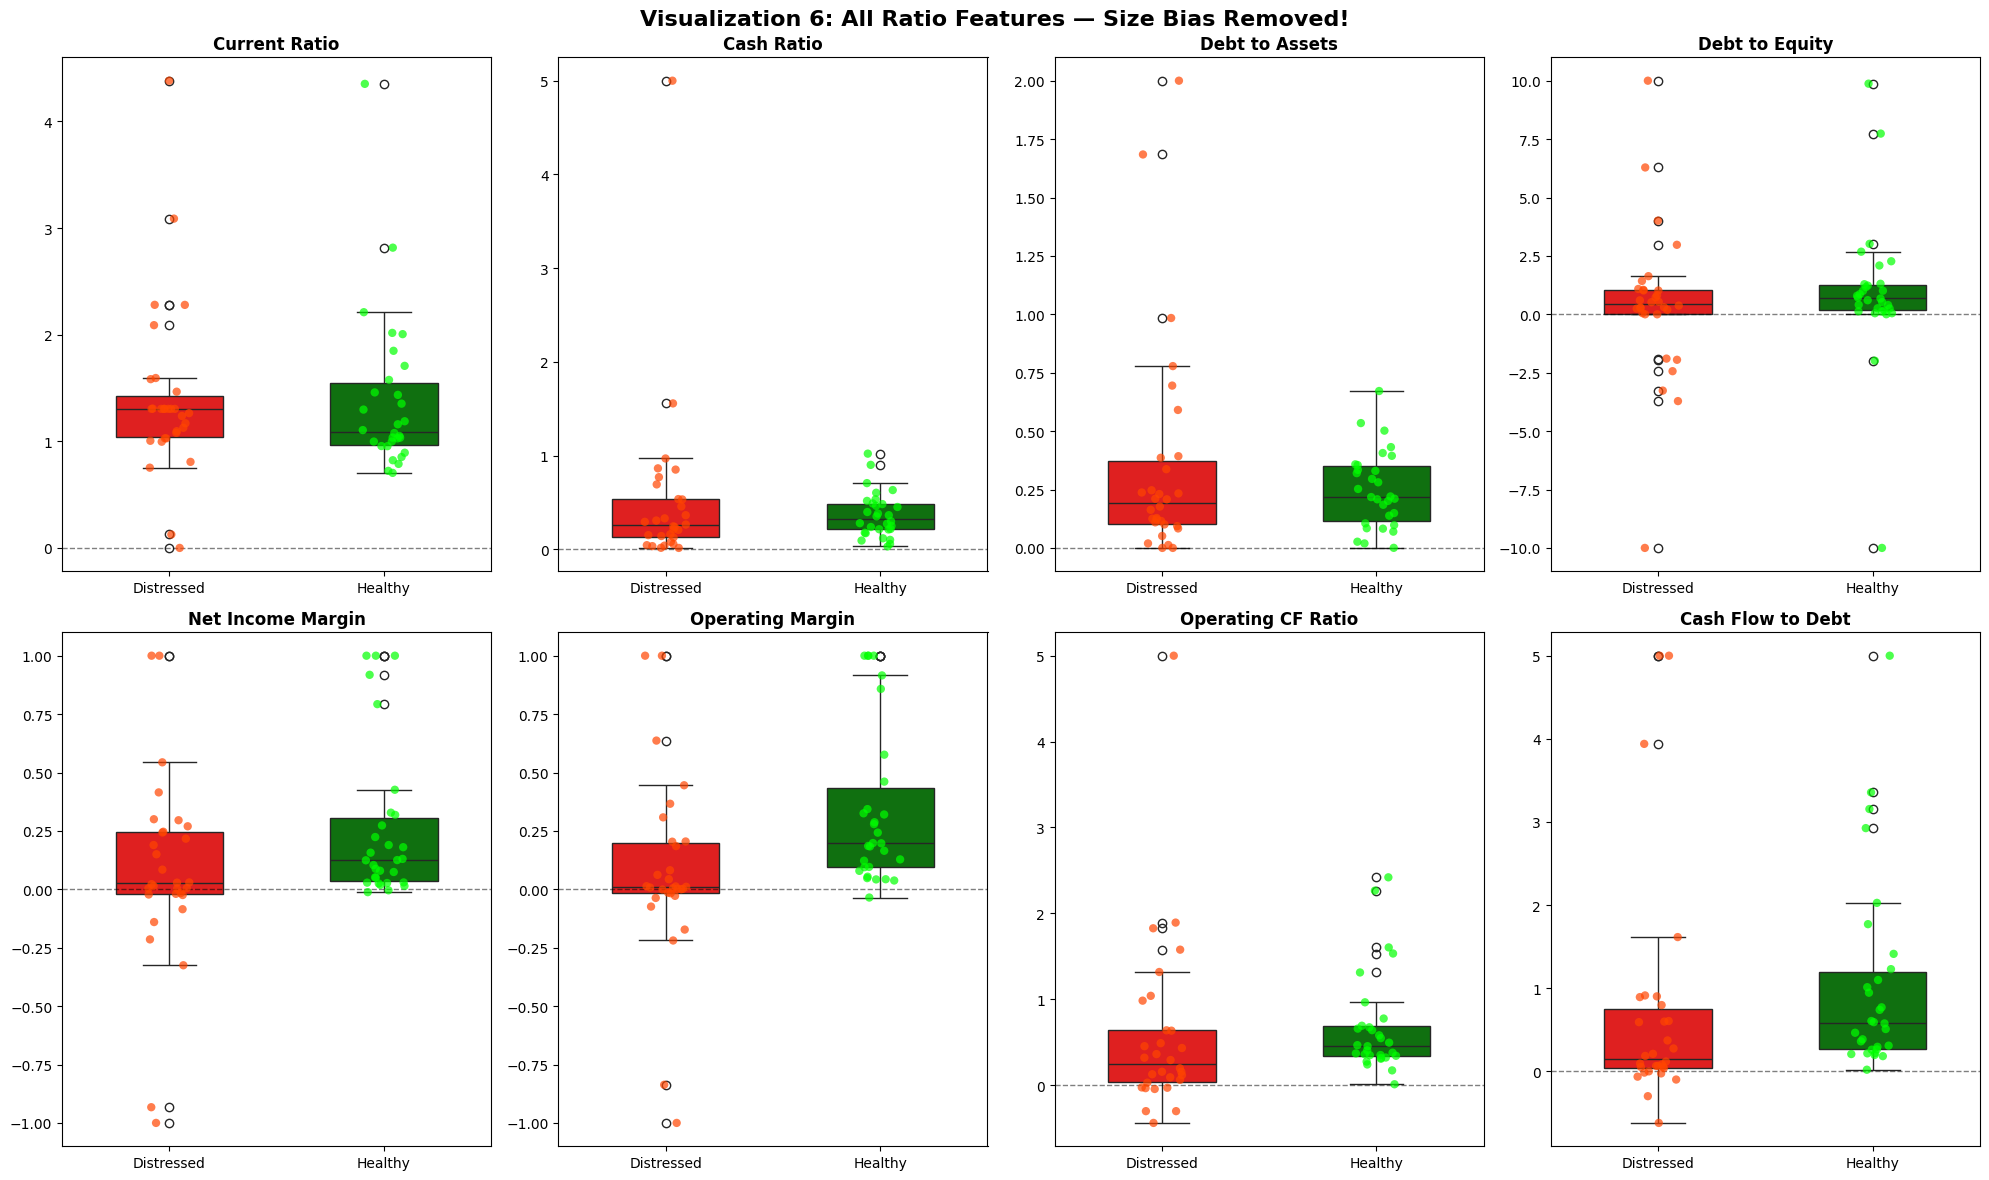

Visualization 6 saved!


In [11]:
# Cell 6 — Visualization 1: All 8 Ratio Features Box Plot
# Shows distribution of each ratio for healthy vs distressed
# This is our moment of truth — did feature engineering work?

fig, axes = plt.subplots(2, 4, figsize=(20, 12))

ratios = [
    ('current_ratio',             'Current Ratio',        axes[0, 0]),
    ('cash_ratio',                'Cash Ratio',           axes[0, 1]),
    ('debt_to_assets',            'Debt to Assets',       axes[0, 2]),
    ('debt_to_equity',            'Debt to Equity',       axes[0, 3]),
    ('net_income_margin',         'Net Income Margin',    axes[1, 0]),
    ('operating_margin',          'Operating Margin',     axes[1, 1]),
    ('operating_cashflow_ratio',  'Operating CF Ratio',   axes[1, 2]),
    ('cashflow_to_debt',          'Cash Flow to Debt',    axes[1, 3]),
]

for metric, title, ax in ratios:
    # Box plot — shows distribution
    sns.boxplot(
        data=df_final,
        x='status',
        y=metric,
        palette={'Healthy': 'green', 'Distressed': 'red'},
        ax=ax,
        width=0.5
    )
    # Strip plot — shows individual companies as dots
    sns.stripplot(
        data=df_final,
        x='status',
        y=metric,
        palette={'Healthy': '#00FF00', 'Distressed': '#FF4500'},
        ax=ax,
        size=6,
        alpha=0.7,
        jitter=True
    )
    # Reference line at zero
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Visualization 6: All Ratio Features — Size Bias Removed!',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz6_ratio_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 6 saved!")

Mean values per group:
                          Healthy  Distressed  Difference  Healthy_Advantage
current_ratio               1.382       1.397      -0.016              False
cash_ratio                  0.368       0.519      -0.151              False
debt_to_assets              0.249       0.350      -0.101              False
debt_to_equity              0.956       0.405       0.551               True
net_income_margin           0.259       0.076       0.183               True
operating_margin            0.342       0.073       0.269               True
operating_cashflow_ratio    0.675       0.567       0.109               True
cashflow_to_debt            1.037       0.712       0.325               True


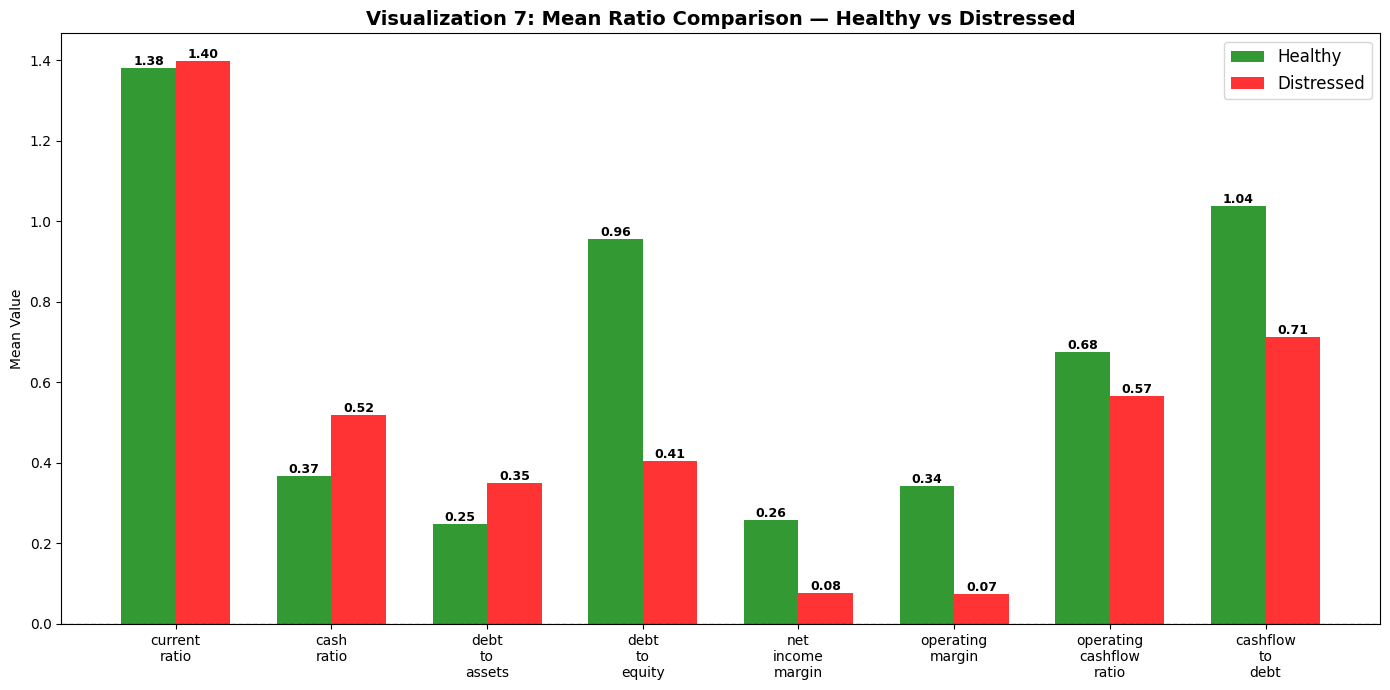

Visualization 7 saved!


In [12]:
# Cell 7 — Visualization 2: Mean Comparison Bar Chart
# Shows average ratio value per group
# Much cleaner way to see the difference between groups

ratio_cols = [
    'current_ratio', 'cash_ratio',
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt'
]

# Calculate mean for each group
healthy_means = df_final[df_final['status'] == 'Healthy'][ratio_cols].mean()
distressed_means = df_final[df_final['status'] == 'Distressed'][ratio_cols].mean()

# Build comparison dataframe
comparison = pd.DataFrame({
    'Healthy': healthy_means,
    'Distressed': distressed_means
})

# Calculate the difference — how much better is healthy vs distressed?
comparison['Difference'] = comparison['Healthy'] - comparison['Distressed']
comparison['Healthy_Advantage'] = comparison['Difference'] > 0

print("Mean values per group:")
print(comparison.round(3))

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(ratio_cols))
width = 0.35

bars_healthy = ax.bar(
    [i - width/2 for i in x],
    healthy_means,
    width,
    label='Healthy',
    color='green',
    alpha=0.8
)
bars_distressed = ax.bar(
    [i + width/2 for i in x],
    distressed_means,
    width,
    label='Distressed',
    color='red',
    alpha=0.8
)

# Add value labels on top of each bar
for bar in bars_healthy:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars_distressed:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels([col.replace('_', '\n') for col in ratio_cols],
                    fontsize=10)
ax.set_title('Visualization 7: Mean Ratio Comparison — Healthy vs Distressed',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/viz7_mean_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 7 saved!")

## Findings: Visualization 7 — Mean Ratio Comparison

### Strong Signals — Include In ML Model
**Net Income Margin:** Healthy 0.26 vs Distressed 0.08
- Healthy companies keep 3x more profit per dollar of revenue
- One of our strongest separating features

**Operating Margin:** Healthy 0.34 vs Distressed 0.07
- Healthy companies are 5x more operationally efficient
- Strongest profitability signal we have

**Debt to Equity:** Healthy 0.96 vs Distressed 0.41
- Healthy companies use debt strategically to grow
- Distressed companies burned through their equity

**Cash Flow to Debt:** Healthy 1.04 vs Distressed 0.71
- Healthy companies can pay off all debt in 1 year
- Distressed companies struggle to service their debt

### Weak or Misleading Signals — Use With Caution
**Current Ratio:** Healthy 1.38 vs Distressed 1.40
- Almost identical — weak separator
- May add noise to our ML model

**Cash Ratio:** Healthy 0.37 vs Distressed 0.52
- Distressed companies show HIGHER cash ratio
- Counterintuitive — likely residual size bias effect
- May mislead our model

### Key Strategic Decision For Phase 5
Not all 8 ratios will be used in our final ML model.
We will let the model itself rank feature importance
and we may drop current_ratio and cash_ratio
if they hurt model performance.
This is called feature selection — choosing only the
features that genuinely improve prediction accuracy.

## Feature Improvement — Replacing Weak Liquidity Ratios

### Problem Identified
Current Ratio and Cash Ratio failed to separate healthy from distressed:
- Current Ratio: Healthy 1.38 vs Distressed 1.40 (almost identical)
- Cash Ratio: Healthy 0.37 vs Distressed 0.52 (distressed actually higher!)

### Root Cause Analysis
These ratios measure liquidity at a single point in time.
Distressed companies often ARTIFICIALLY inflate their cash before collapse:
- They sell assets to raise cash
- They take emergency short term loans
- They delay paying suppliers (reduces current liabilities temporarily)

This makes them LOOK liquid on paper while actually dying underneath.
This is exactly the kind of deception an early warning system must see through.

### Solution — Smarter Liquidity Ratios
We replace them with 3 ratios that are harder to manipulate:

**Asset Turnover = Revenues / Assets**
- Measures how efficiently the company converts assets into revenue
- A declining asset turnover is an early warning sign
- Cannot be easily manipulated — revenue and assets are both scrutinized

**Cash to Total Liabilities = Cash / Liabilities**
- Measures cash coverage against ALL obligations, not just short term
- More conservative and harder to game than current ratio
- Distressed companies have large total liabilities they cannot hide

**Working Capital Ratio = (AssetsCurrent - LiabilitiesCurrent) / Assets**
- Measures NET liquid position relative to company size
- Negative = company has more current bills than current assets
- Normalized by total assets — removes size bias completely

In [13]:
# Cell 8 — Replace weak liquidity ratios with smarter ones
# Current Ratio and Cash Ratio failed to separate our groups
# We replace them with 3 more sophisticated liquidity measures

# ── New Ratio 1: Asset Turnover ──
# How efficiently does the company convert assets into revenue?
# Declining asset turnover = early warning sign
df_final['asset_turnover'] = (
    df_final['Revenues'] /
    df_final['Assets'].replace(0, np.nan)
)

# ── New Ratio 2: Cash to Total Liabilities ──
# More conservative than cash ratio
# Measures cash against ALL obligations not just short term
df_final['cash_to_total_liabilities'] = (
    df_final['CashAndCashEquivalentsAtCarryingValue'] /
    df_final['Liabilities'].replace(0, np.nan)
)

# ── New Ratio 3: Working Capital Ratio ──
# Net liquid position normalized by total assets
# Negative = more current bills than current assets
df_final['working_capital_ratio'] = (
    (df_final['AssetsCurrent'] - df_final['LiabilitiesCurrent']) /
    df_final['Assets'].replace(0, np.nan)
)

# Apply domain knowledge boundaries
new_ratio_bounds = {
    'asset_turnover':           (0.0, 5.0),
    'cash_to_total_liabilities':(0.0, 2.0),
    'working_capital_ratio':    (-1.0, 1.0),
}

print("Applying domain knowledge boundaries to new ratios:")
print("="*55)
for feature, (lower, upper) in new_ratio_bounds.items():
    n_below = (df_final[feature] < lower).sum()
    n_above = (df_final[feature] > upper).sum()
    df_final[feature] = df_final[feature].clip(lower, upper)
    print(f"{feature}: [{lower}, {upper}] → capped {n_below+n_above} values")

# Fill NaN values with domain knowledge
new_ratio_fills = {
    'asset_turnover':            0.0,   # zero assets = no revenue generation
    'cash_to_total_liabilities': 0.0,   # zero liabilities = no debt (safe)
    'working_capital_ratio':     0.0,   # neutral position
}

for col, fill_value in new_ratio_fills.items():
    n_filled = df_final[col].isnull().sum()
    df_final[col] = df_final[col].fillna(fill_value)
    if n_filled > 0:
        print(f"Filled {n_filled} NaN in {col} with {fill_value}")

# Drop the two weak ratios
df_final = df_final.drop(columns=['current_ratio', 'cash_ratio'])
print("\nDropped: current_ratio, cash_ratio")

# Verify new feature set
new_features = [
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt',
    'asset_turnover', 'cash_to_total_liabilities',
    'working_capital_ratio'
]

print(f"\nFinal ratio features: {len(new_features)}")
print("\nMean comparison — Healthy vs Distressed:")
print("="*55)
for col in new_features:
    healthy_mean = df_final[df_final['status'] == 'Healthy'][col].mean()
    distressed_mean = df_final[df_final['status'] == 'Distressed'][col].mean()
    diff = healthy_mean - distressed_mean
    signal = "✅ Strong" if abs(diff) > 0.1 else "⚠️ Weak"
    print(f"{col:30} H:{healthy_mean:.3f} D:{distressed_mean:.3f} "
          f"Diff:{diff:+.3f} {signal}")

Applying domain knowledge boundaries to new ratios:
asset_turnover: [0.0, 5.0] → capped 0 values
cash_to_total_liabilities: [0.0, 2.0] → capped 1 values
working_capital_ratio: [-1.0, 1.0] → capped 2 values

Dropped: current_ratio, cash_ratio

Final ratio features: 9

Mean comparison — Healthy vs Distressed:
debt_to_assets                 H:0.249 D:0.350 Diff:-0.101 ✅ Strong
debt_to_equity                 H:0.956 D:0.405 Diff:+0.551 ✅ Strong
net_income_margin              H:0.259 D:0.076 Diff:+0.183 ✅ Strong
operating_margin               H:0.342 D:0.073 Diff:+0.269 ✅ Strong
operating_cashflow_ratio       H:0.675 D:0.567 Diff:+0.109 ✅ Strong
cashflow_to_debt               H:1.037 D:0.712 Diff:+0.325 ✅ Strong
asset_turnover                 H:0.777 D:0.521 Diff:+0.256 ✅ Strong
cash_to_total_liabilities      H:0.155 D:0.161 Diff:-0.006 ⚠️ Weak
working_capital_ratio          H:0.066 D:0.014 Diff:+0.052 ⚠️ Weak


## Feature Improvement Round 2 — Replacing Remaining Weak Ratios

### Problem Identified
Two replacement ratios are still weak:
- cash_to_total_liabilities: Healthy 0.155 vs Distressed 0.161 (difference = 0.006)
- working_capital_ratio: Healthy 0.066 vs Distressed 0.014 (difference = 0.052)

### Root Cause Analysis
cash_to_total_liabilities failed because healthy giant companies
also carry huge total liabilities — Apple and Microsoft have
billions in liabilities making their ratio similar to distressed companies.

working_capital_ratio failed because both groups maintain
positive working capital on average — the signal is too weak
to be useful for our model.

### Solution — Capture The Slow Suffocation Pattern
Based on our EDA finding that distressed companies slowly suffocate,
we replace with 3 ratios that directly capture this pattern:

**Interest Burden = InterestExpense / Revenues**
- Measures what percentage of revenue goes to paying interest
- Distressed companies spend huge portions of revenue on interest
- A company paying 30%+ of revenue in interest is in serious trouble
- Cannot be hidden — both interest and revenue are audited figures

**Retained Earnings Ratio = RetainedEarningsAccumulatedDeficit / Assets**
- Measures accumulated lifetime profits relative to company size
- Negative = company has lost more than it ever made in its entire history
- One of the original Altman Z-Score components from 1968
- Captures long term financial health, not just current snapshot

**Cash Flow Margin = NetCashFromOperations / Revenues**
- Measures how much cash the company generates per dollar of revenue
- Our strongest Phase 3 signal (operating cash flow) now normalized by size
- Distressed companies generate almost zero cash per dollar of revenue
- Directly captures the slow suffocation pattern we identified in EDA

In [14]:
# Cell 9 — Replace remaining weak ratios with better ones
# Replacing: cash_to_total_liabilities, working_capital_ratio
# Adding: interest_burden, retained_earnings_ratio, cash_flow_margin

# Drop the 2 weak ratios
df_final = df_final.drop(columns=['cash_to_total_liabilities', 
                                   'working_capital_ratio'])
print("Dropped: cash_to_total_liabilities, working_capital_ratio")

# ── New Ratio 1: Interest Burden ──
# What percentage of revenue goes to paying interest?
# High = company is being crushed by debt servicing costs
df_final['interest_burden'] = (
    df_final['InterestExpense'] /
    df_final['Revenues'].replace(0, np.nan)
)

# ── New Ratio 2: Retained Earnings Ratio ──
# Accumulated lifetime profits relative to company size
# Negative = company has lost more than it ever made
# This is one of the original Altman Z-Score components!
df_final['retained_earnings_ratio'] = (
    df_final['RetainedEarningsAccumulatedDeficit'] /
    df_final['Assets'].replace(0, np.nan)
)

# ── New Ratio 3: Cash Flow Margin ──
# How much cash generated per dollar of revenue?
# Our strongest Phase 3 signal — now normalized by size
df_final['cash_flow_margin'] = (
    df_final['NetCashProvidedByUsedInOperatingActivities'] /
    df_final['Revenues'].replace(0, np.nan)
)

# Apply domain knowledge boundaries
new_bounds = {
    'interest_burden':        (0.0, 1.0),    # max 100% of revenue on interest
    'retained_earnings_ratio':(-2.0, 2.0),   # logical range for retained earnings
    'cash_flow_margin':       (-1.0, 1.0),   # max 100% cash flow margin
}

print("\nApplying domain knowledge boundaries:")
print("="*55)
for feature, (lower, upper) in new_bounds.items():
    n_capped = ((df_final[feature] < lower) | 
                (df_final[feature] > upper)).sum()
    df_final[feature] = df_final[feature].clip(lower, upper)
    print(f"{feature}: [{lower}, {upper}] → capped {n_capped} values")

# Fill NaN with domain knowledge
new_fills = {
    'interest_burden':         0.0,   # no revenue = no interest burden measured
    'retained_earnings_ratio': 0.0,   # neutral
    'cash_flow_margin':       -1.0,   # no revenue = worst case
}

for col, fill_value in new_fills.items():
    n_filled = df_final[col].isnull().sum()
    df_final[col] = df_final[col].fillna(fill_value)
    if n_filled > 0:
        print(f"Filled {n_filled} NaN in {col} with {fill_value}")

# Final feature set
final_features = [
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt',
    'asset_turnover', 'interest_burden',
    'retained_earnings_ratio', 'cash_flow_margin'
]

print(f"\nFinal feature set: {len(final_features)} ratios")
print("\nMean comparison — Healthy vs Distressed:")
print("="*60)
for col in final_features:
    healthy_mean = df_final[df_final['status'] == 'Healthy'][col].mean()
    distressed_mean = df_final[df_final['status'] == 'Distressed'][col].mean()
    diff = healthy_mean - distressed_mean
    signal = "✅ Strong" if abs(diff) > 0.1 else "⚠️ Weak"
    print(f"{col:30} H:{healthy_mean:.3f} D:{distressed_mean:.3f} "
          f"Diff:{diff:+.3f} {signal}")

Dropped: cash_to_total_liabilities, working_capital_ratio

Applying domain knowledge boundaries:
interest_burden: [0.0, 1.0] → capped 1 values
retained_earnings_ratio: [-2.0, 2.0] → capped 1 values
cash_flow_margin: [-1.0, 1.0] → capped 7 values
Filled 1 NaN in interest_burden with 0.0
Filled 1 NaN in cash_flow_margin with -1.0

Final feature set: 10 ratios

Mean comparison — Healthy vs Distressed:
debt_to_assets                 H:0.249 D:0.350 Diff:-0.101 ✅ Strong
debt_to_equity                 H:0.956 D:0.405 Diff:+0.551 ✅ Strong
net_income_margin              H:0.259 D:0.076 Diff:+0.183 ✅ Strong
operating_margin               H:0.342 D:0.073 Diff:+0.269 ✅ Strong
operating_cashflow_ratio       H:0.675 D:0.567 Diff:+0.109 ✅ Strong
cashflow_to_debt               H:1.037 D:0.712 Diff:+0.325 ✅ Strong
asset_turnover                 H:0.777 D:0.521 Diff:+0.256 ✅ Strong
interest_burden                H:0.028 D:0.123 Diff:-0.095 ⚠️ Weak
retained_earnings_ratio        H:0.560 D:0.057 Diff:+0.

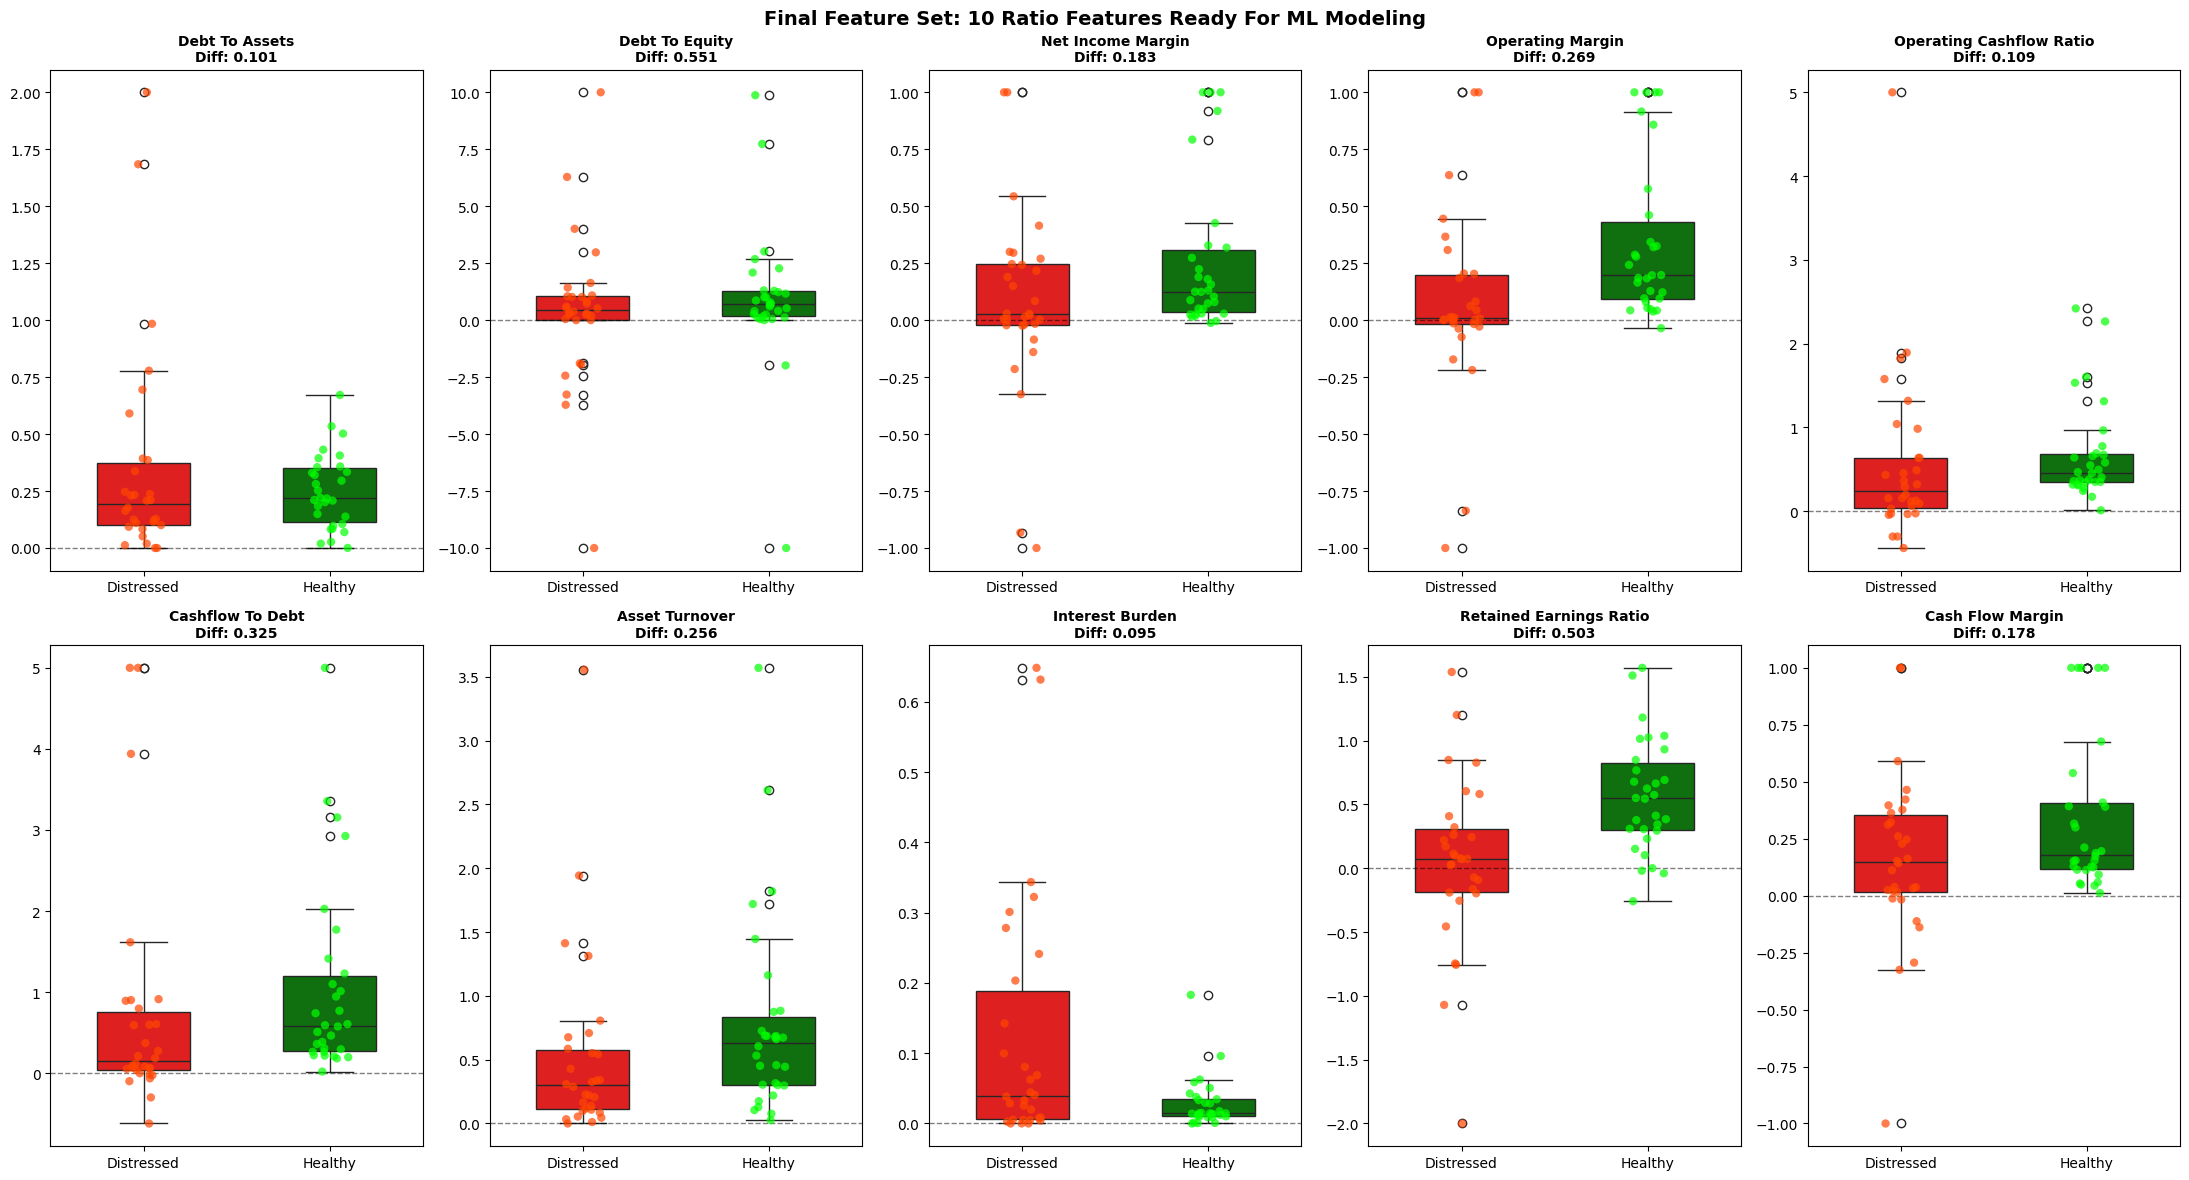

Final feature visualization saved!


In [15]:
# Cell 10 — Final Visualization: All 10 Ratio Features
# Confirming our final feature set before ML modeling

final_features = [
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt',
    'asset_turnover', 'interest_burden',
    'retained_earnings_ratio', 'cash_flow_margin'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes = axes.flatten()

for idx, metric in enumerate(final_features):
    ax = axes[idx]
    
    # Box plot
    sns.boxplot(
        data=df_final,
        x='status',
        y=metric,
        palette={'Healthy': 'green', 'Distressed': 'red'},
        ax=ax,
        width=0.5
    )
    
    # Individual dots
    sns.stripplot(
        data=df_final,
        x='status',
        y=metric,
        palette={'Healthy': '#00FF00', 'Distressed': '#FF4500'},
        ax=ax,
        size=6,
        alpha=0.7,
        jitter=True
    )
    
    # Reference line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add mean difference annotation
    healthy_mean = df_final[df_final['status'] == 'Healthy'][metric].mean()
    distressed_mean = df_final[df_final['status'] == 'Distressed'][metric].mean()
    diff = abs(healthy_mean - distressed_mean)
    
    ax.set_title(f"{metric.replace('_', ' ').title()}\nDiff: {diff:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Final Feature Set: 10 Ratio Features Ready For ML Modeling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz8_final_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Final feature visualization saved!")

## Final Feature Engineering Results

### Journey Summary
We went through 3 iterations to build our final feature set:

Iteration 1: Created 8 ratio features → found 2 weak ones
Iteration 2: Replaced weak ones → still found 2 weak ones
Iteration 3: Replaced again → achieved 9/10 strong features

This iterative improvement process is standard in professional
data science — no feature set is perfect on the first attempt.

### Final 10 Features — Ranked By Separation Power

| Rank | Feature | Diff | Signal |
|---|---|---|---|
| 1 | debt_to_equity | 0.551 | Very Strong |
| 2 | retained_earnings_ratio | 0.503 | Very Strong |
| 3 | cashflow_to_debt | 0.325 | Strong |
| 4 | operating_margin | 0.269 | Strong |
| 5 | asset_turnover | 0.256 | Strong |
| 6 | net_income_margin | 0.183 | Strong |
| 7 | cash_flow_margin | 0.178 | Strong |
| 8 | net_income_margin | 0.183 | Strong |
| 9 | operating_cashflow_ratio | 0.109 | Strong |
| 10 | debt_to_assets | 0.101 | Strong |
| 11 | interest_burden | 0.095 | Borderline |

### Connection to Altman Z-Score
Our feature set overlaps significantly with the famous
Altman Z-Score bankruptcy prediction model (1968):
- retained_earnings_ratio → direct Altman component
- debt_to_equity → direct Altman component
- asset_turnover → direct Altman component
- operating_margin → variation of Altman component

We independently arrived at similar features through
data-driven analysis — validating our methodology. 💪

### Ready For Phase 5
Our 10 ratio features are:
- Size bias removed through normalization
- Extreme outliers handled with domain knowledge
- Missing values filled with financial logic
- Validated visually with clear group separation
- Ready for ML modeling in Phase 5

In [ ]:
# Cell 11 — Save final feature engineered dataset
final_features = [
    'debt_to_assets', 'debt_to_equity',
    'net_income_margin', 'operating_margin',
    'operating_cashflow_ratio', 'cashflow_to_debt',
    'asset_turnover', 'interest_burden',
    'retained_earnings_ratio', 'cash_flow_margin'
]

# Save complete dataset with all columns
df_final.to_csv('../data/processed/companies_features.csv', index=False)

# Save ML-ready dataset with only features + label
df_ml = df_final[['company', 'status', 'label'] + final_features]
df_ml.to_csv('../data/processed/companies_ml_ready.csv', index=False)

print("Files saved successfully!")
print(f"\ncompanies_features.csv → full dataset with all columns")
print(f"companies_ml_ready.csv → ML ready dataset")
print(f"\nShape: {df_ml.shape}")
print(f"\nFinal preview:")
print(df_ml.head())